# BRONZE

In [265]:
#!pip install pyreadstat rapidfuzz

import pandas as pd
import os
import pyreadstat # for reading SPSS files
import rapidfuzz

# SPSS
For loading SPSS files and extracting the labels into a dataframe, ChatGPT was used.

### Loading SPSS files

In [3]:
spss_base = r"c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS"

# For waves that have multiple country-specific files I map them to the same wave ID
spss_files = {
    "ESS1": ["ESS1e06_7_spss"],
    "ESS2": ["ESS2e03_6_spss", "ESS2IT_spss"],
    "ESS3": ["ESS3e03_7_spss", "ESS3LV_spss", "ESS3RO_spss"],
    "ESS4": ["ESS4e04_6_spss", "ESS4AT_spss", "ESS4LT_spss"],
    "ESS5": ["ESS5e03_6_spss", "ESS5ATe1_1_spss"],
    "ESS6": ["ESS6e02_7_spss"],
    "ESS7": ["ESS7e02_3_spss"],
    "ESS8": ["ESS8e02_3_spss"],
    "ESS9": ["ESS9e03_2_spss"],
    "ESS10": ["ESS10e03_2_spss"],
    "ESS11": ["ESS11e04_0_spss"],
}

### Extracting labels into a dataframe

In [4]:
# Reading labels
meta_rows = []

for wave, folders in spss_files.items():
    for folder in folders:
        # The .sav file name is the folder name minus the trailing "_spss"
        base_name = folder.replace("_spss", "")
        sav_path = os.path.join(spss_base, folder, base_name + ".sav")

        print(f"Reading labels from {sav_path} for {wave} ...")

        df_spss, meta = pyreadstat.read_sav(sav_path)

        col_names = meta.column_names # variable names
        col_labels = meta.column_labels # corresponding labels

        for name, label in zip(col_names, col_labels):
            meta_rows.append({
                "wave": wave,
                "variable": name,
                "label": label if label is not None else ""
            })

        # Free memory from SPSS dataframe; we only needed metadata
        del df_spss

# Building combined metadata DataFrame
metadata = pd.DataFrame(meta_rows)

# Droping duplicates that come from multiple country files with same labels
metadata = metadata.drop_duplicates(subset=["wave", "variable", "label"]).reset_index(drop=True)

print("Metadata shape:", metadata.shape)
metadata.head()

metadata.to_csv("ess_variable_labels_all_waves.csv", index=False)

Reading labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS1e06_7_spss\ESS1e06_7.sav for ESS1 ...
Reading labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS2e03_6_spss\ESS2e03_6.sav for ESS2 ...
Reading labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS2IT_spss\ESS2IT.sav for ESS2 ...
Reading labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS3e03_7_spss\ESS3e03_7.sav for ESS3 ...
Reading labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS3LV_spss\ESS3LV.sav for ESS3 ...
Reading labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS3RO_spss\ESS3RO.sav for ESS3 ...
Reading labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS4e04_6_spss\ESS4e04_6.sav for ESS4 ...
Reading labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS4AT_spss\ESS4AT.sav for ESS4 ...
Reading labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS4

In [174]:
metadata.to_csv("ess_variable_labels.csv", index=False)

# Reading CSV files

In [212]:
ess1 = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS1e06_7/ESS1e06_7.csv")

ess2_no_it = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS2e03_6/ESS2e03_6.csv")
ess2_it = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS2IT/ESS2IT.csv")

ess3_no_lv_ro = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS3e03_7/ESS3e03_7.csv")
ess3_lv = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS3LV/ESS3LV.csv")
ess3_ro = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS3RO/ESS3RO.csv")

ess4_no_at_lt = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS4e04_6/ESS4e04_6.csv")
ess4_at = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS4AT/ESS4AT.csv")
ess4_lt = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS4LT/ESS4LT.csv")

ess5_no_at = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS5e03_6/ESS5e03_6.csv")
ess5_at = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS5ATe1_1/ESS5ATe1_1.csv")

ess6 = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS6e02_7/ESS6e02_7.csv")

ess7 = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS7e02_3/ESS7e02_3.csv")

ess8 = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS8e02_3/ESS8e02_3.csv")

ess9 = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS9e03_2/ESS9e03_2.csv")

ess10 = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS10/ESS10.csv")

ess11 = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS11 (3)/ESS11.csv")

C:\Users\zosia\AppData\Local\Temp\ipykernel_17676\1517671423.py:1: DtypeWarning: Columns (167) have mixed types. Specify dtype option on import or set low_memory=False.
  ess1 = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS1e06_7/ESS1e06_7.csv")
C:\Users\zosia\AppData\Local\Temp\ipykernel_17676\1517671423.py:3: DtypeWarning: Columns (165) have mixed types. Specify dtype option on import or set low_memory=False.
  ess2_no_it = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS2e03_6/ESS2e03_6.csv")
C:\Users\zosia\AppData\Local\Temp\ipykernel_17676\1517671423.py:6: DtypeWarning: Columns (170) have mixed types. Specify dtype option on import or set low_memory=False.
  ess3_no_lv_ro = pd.read_csv("/Users/zosia/OneDrive/Dokumenty/DS&BA/magisterka/csv/ESS3e03_7/ESS3e03_7.csv")
C:\Users\zosia\AppData\Local\Temp\ipykernel_17676\1517671423.py:8: DtypeWarning: Columns (172,175,178,180) have mixed types. Specify dtype option on import or set low_memory=F

# SILVER

### Creating datasets ess2, ess3, ess4, ess5 by combining the datasets within each wave

#### ESS2
Basic information for both ESS2 datasets

In [213]:
print("ess2_no_it:", ess2_no_it.shape[0], "rows,", ess2_no_it.shape[1], "columns")
print("ess2_it:", ess2_it.shape[0], "rows,", ess2_it.shape[1], "columns")

ess2_no_it: 47537 rows, 604 columns
ess2_it: 1529 rows, 604 columns


Finding missing columns in each dataset

In [214]:
cols_no_it = list(ess2_no_it.columns)
cols_it = list(ess2_it.columns)

# Finding all unique variable names across both datasets
all_columns = list(set(cols_no_it).union(set(cols_it)))

# Finding which columns are missing in each dataset
missing_in_no_it = [c for c in all_columns if c not in ess2_no_it.columns]
missing_in_it = [c for c in all_columns if c not in ess2_it.columns]

# Finding columns that exist in both datasets
common_columns = [c for c in ess2_no_it.columns if c in ess2_it.columns]

print("Missing in ess2_no_it:", missing_in_no_it)
print("Missing in ess2_it:", missing_in_it)
print("Common variables:", len(common_columns))

Missing in ess2_no_it: []
Missing in ess2_it: []
Common variables: 604


Aligning columns

In [215]:
# Adding missing columns and filling them with NaN
for col in missing_in_no_it:
    ess2_no_it[col] = pd.NA

for col in missing_in_it:
    ess2_it[col] = pd.NA

# Reordering columns so both dataframes match
ess2_no_it = ess2_no_it[all_columns]
ess2_it = ess2_it[all_columns]

Combining two datasets

In [216]:
ess2 = pd.concat([ess2_no_it, ess2_it], ignore_index=True)

print("ESS2:")
print("Rows:", ess2.shape[0])
print("Columns:", ess2.shape[1])

ESS2:
Rows: 49066
Columns: 604


#### ESS3
Basic information for all three ESS3 datastes

In [217]:
print("ess3_no_lv_ro:", ess3_no_lv_ro.shape[0], "rows,", ess3_no_lv_ro.shape[1], "columns")
print("ess3_lv:", ess3_lv.shape[0], "rows,", ess3_lv.shape[1], "columns")
print("ess3_ro:", ess3_ro.shape[0], "rows,", ess3_ro.shape[1], "columns")

ess3_no_lv_ro: 43000 rows, 519 columns
ess3_lv: 1960 rows, 519 columns
ess3_ro: 2139 rows, 519 columns


Finding missing columns in each dataset

In [218]:
# Getting all column names from each dataset
cols_main = list(ess3_no_lv_ro.columns)
cols_lv = list(ess3_lv.columns)
cols_ro = list(ess3_ro.columns)

# Finding all unique variable names across all three datasets
all_columns = list(set(cols_main).union(set(cols_lv)).union(set(cols_ro)))

# Finding columns that are missing in each dataset
missing_in_main = [c for c in all_columns if c not in ess3_no_lv_ro.columns]
missing_in_lv = [c for c in all_columns if c not in ess3_lv.columns]
missing_in_ro = [c for c in all_columns if c not in ess3_ro.columns]

# Finding columns that exist in all three datasets
common_columns = [c for c in ess3_no_lv_ro.columns if c in ess3_lv.columns and c in ess3_ro.columns]

print("Missing in ess3_no_lv_ro:", missing_in_main)
print("Missing in ess_lv:", missing_in_lv)
print("Missing in ess_ro:", missing_in_ro)
print("Common variables:", len(common_columns))

Missing in ess3_no_lv_ro: []
Missing in ess_lv: []
Missing in ess_ro: []
Common variables: 519


Aligning columns

In [219]:
# Adding missing columns and filling them with NaN
for col in missing_in_main:
    ess3_no_lv_ro[col] = pd.NA

for col in missing_in_lv:
    ess_lv[col] = pd.NA

for col in missing_in_ro:
    ess_ro[col] = pd.NA

# Reordering columns so all three dataframes match
ess3_no_lv_ro = ess3_no_lv_ro[all_columns]
ess_lv = ess3_lv[all_columns]
ess_ro = ess3_ro[all_columns]

Combining all three datasets

In [220]:
ess3 = pd.concat([ess3_no_lv_ro, ess3_lv, ess3_ro], ignore_index=True)

print("ESS3:")
print("Rows:", ess3.shape[0])
print("Columns:", ess3.shape[1])

ESS3:
Rows: 47099
Columns: 519


#### ESS4
Basic information for all three ESS4 datastes

In [221]:
print("ess4_no_at_lt:", ess4_no_at_lt.shape[0], "rows,", ess4_no_at_lt.shape[1], "columns")
print("ess4_at:", ess4_at.shape[0], "rows,", ess4_at.shape[1], "columns")
print("cols_lt:", ess4_lt.shape[0], "rows,", ess4_lt.shape[1], "columns")

ess4_no_at_lt: 56752 rows, 674 columns
ess4_at: 2255 rows, 673 columns
cols_lt: 2002 rows, 673 columns


Finding missing columns in each dataset

In [222]:
# Getting all column names from each dataset
cols_main = set(ess4_no_at_lt.columns)
cols_at = set(ess4_at.columns)
cols_lt = set(ess4_lt.columns)

# Finding all unique variable names across all three datasets
all_columns = list(cols_main.union(cols_at).union(cols_lt))

# Finding columns that are missing in each dataset
missing_in_main = [c for c in all_columns if c not in ess4_no_at_lt.columns]
missing_in_at = [c for c in all_columns if c not in ess4_at.columns]
missing_in_lt = [c for c in all_columns if c not in ess4_lt.columns]

# Finding columns that exist in all three datasets
common_columns = [c for c in ess4_no_at_lt.columns if c in ess4_at.columns and c in ess4_lt.columns]

print("Missing in ess4_no_at_lt:", missing_in_main)
print("Missing in ess4_at:", missing_in_at)
print("Missing in ess4_lt:", missing_in_lt)
print("Common columns:", len(common_columns))

Missing in ess4_no_at_lt: []
Missing in ess4_at: ['anweight']
Missing in ess4_lt: ['anweight']
Common columns: 673


Aligning columns

In [223]:
# Adding missing columns and filling them with NaN
for col in missing_in_main:
    ess4_no_at_lt[col] = pd.NA

for col in missing_in_at:
    ess4_at[col] = pd.NA

for col in missing_in_lt:
    ess4_lt[col] = pd.NA
    
# Reordering columns so all three dataframes match
ess4_no_at_lt = ess4_no_at_lt[all_columns]
ess4_at = ess4_at[all_columns]
ess4_lt = ess4_lt[all_columns]

Combining all three datasets

In [224]:
ess3 = pd.concat([ess3_no_lv_ro, ess_lv, ess_ro], ignore_index=True)

ess4 = pd.concat([ess4_no_at_lt, ess4_at, ess4_lt], ignore_index=True)

print("ESS4:")
print("Rows:", ess4.shape[0])
print("Columns:", ess4.shape[1])

ESS4:
Rows: 61009
Columns: 674


#### ESS5
Basic information for both ESS5 datasets

In [225]:
print("ess5_no_at:", ess5_no_at.shape[0], "rows,", ess5_no_at.shape[1], "columns")
print("ess5_at:", ess5_at.shape[0], "rows,", ess5_at.shape[1], "columns")

ess5_no_at: 52458 rows, 675 columns
ess5_at: 2259 rows, 686 columns


Finding missing columns in each dataset

In [226]:
cols_no_at = list(ess5_no_at.columns)
cols_at = list(ess5_at.columns)

# Finding all unique variable names across both datasets
all_columns = list(set(cols_no_at).union(set(cols_at)))

# Finding which columns are missing in each dataset
missing_in_no_at = [c for c in all_columns if c not in ess5_no_at.columns]
missing_in_at = [c for c in all_columns if c not in ess5_at.columns]

# Finding columns that exist in both datasets
common_columns = [c for c in ess5_no_at.columns if c in ess5_at.columns]

print("Missing in ess5_no_at:", missing_in_no_at)
print("Missing in ess5_at:", missing_in_at)
print("Common variables:", len(common_columns))

Missing in ess5_no_at: ['prtclaie', 'prtmbaie', 'edlvfdat', 'rlgdeaat', 'edlvdat', 'edlvmdat', 'rlgdnaat', 'cutheqat', 'edlvpdat', 'prtmbbat', 'prtvtaat', 'prtclbat', 'dsdclvat', 'mloincat']
Missing in ess5_at: ['prtmbbie', 'prtclcie', 'anweight']
Common variables: 672


Variable name comparison:
Missing in ess5_no_at: 
'edlvmdat','cutheqat', 'dsdclvat', 'rlgdnaat', 'edlvpdat', 'mloincat', 'rlgdeaat', 'edlvfdat', 'prtmbbat', 'prtclbat', 'edlvdat', 'prtvtaat'  - related to Austria, valid

'prtclaie' - "Which party feel closer to, Ireland"

'prtmbaie' - "Member of which party, Ireland"


Missing in ess5_at:
'anweight' - "Analysis weights"

'prtclcie' - "Which party feel closer to, Ireland"

'prtmbbie' - "Member of which party, Ireland"


### Columns that need renaming
**ess5_at.prtclaie = ess5_no_at.prtclcie**

**ess5_at.prtmbaie = ess5_no_at.prtmbbie**

In [227]:
# Renaming columns
ess5_at.rename(columns={'prtclaie': 'prtclcie', 'prtmbaie': 'prtmbbie'}, inplace=True)

Aligning columns

In [228]:
cols_no_at = list(ess5_no_at.columns)
cols_at = list(ess5_at.columns)

# Finding all unique variable names across both datasets
all_columns = list(set(cols_no_at).union(set(cols_at)))

# Adding missing columns and filling them with NaN
for col in missing_in_no_at:
    ess5_no_at[col] = pd.NA

for col in missing_in_at:
    ess5_at[col] = pd.NA

# Reordering columns so both dataframes match
ess5_no_at = ess5_no_at[all_columns]
ess5_at = ess5_at[all_columns]

Combining two datasets

In [229]:
ess5 = pd.concat([ess5_no_at, ess5_at], ignore_index=True)

print("ESS5:")
print("Rows:", ess5.shape[0])
print("Columns:", ess5.shape[1])

ESS5:
Rows: 54717
Columns: 687


### Creating an ess dictionary

In [230]:
ess = {
    "ESS1": ess1,
    "ESS2": ess2,
    "ESS3": ess3,
    "ESS4": ess4,
    "ESS5": ess5,
    "ESS6": ess6,
    "ESS7": ess7,
    "ESS8": ess8,
    "ESS9": ess9,
    "ESS10": ess10,
    "ESS11": ess11,
}

In [231]:
print("Columns per dataset:")
for name, dataset in ess.items():
    print(name, dataset.shape)

Columns per dataset:
ESS1 (42359, 567)
ESS2 (49066, 604)
ESS3 (47099, 519)
ESS4 (61009, 674)
ESS5 (54717, 687)
ESS6 (54673, 625)
ESS7 (40185, 602)
ESS8 (44387, 535)
ESS9 (49519, 572)
ESS10 (37611, 618)
ESS11 (46162, 676)


In [232]:
feature_list = ["cntry", "agea", "essround", "gndr", "hinctnta", "hincfel", "stfeco", "uempla", "uempli", "eduyrs", "sclmeet", 
                "inmdisc", "sclact", "netusoft", "health", "wkhtot", "aesfdrk", "ppltrst", "ipsuces", "ipgdtim", "iphlppl", 
                "hhmmb", "trstplc", "anweight", "pplhlp", "nwspol", "health", "rlgdgr", "ipcrtiv", "ipeqopt",
                "impdiff", "ipmodst"]

## Checking whether all variables from feature_list + the target variable exist in each dataset and whether their ranges are consistent

There exist some variables in ESS that were used only in some waves. Therefore, I am checking if all our chosen variables exist in all datasets. Then, I am checking if their ranges are the same since it also happens that the possible answers to a question (=possible values of a variable) change between waves. This is usually alongside a slight variable change, however, we still check it to be safe.

In [233]:
import numpy as np

# Define variables to check
target_var = "stflife"
vars_to_check = feature_list + [target_var]

print("--- Variable Range and Presence Check ---")

# Dictionary to track missing variables
missing_report = {}

for wave_name, df in ess.items():
    print(f"\n{'='*30}")
    print(f" WAVE: {wave_name} ")
    print(f"{'='*30}")
    
    missing_in_wave = []
    
    for var in vars_to_check:
        if var in df.columns:
            # Drop NaNs for unique value calculation to see actual data ranges
            unique_vals = np.sort(df[var].dropna().unique())
            
            # Formatting output: if there are many unique values (like age), show min/max
            if len(unique_vals) > 15:
                print(f"Variable: {var:12} | Count: {len(unique_vals):3} | Range: [{min(unique_vals)} - {max(unique_vals)}]")
            else:
                print(f"Variable: {var:12} | Count: {len(unique_vals):3} | Values: {unique_vals}")
        else:
            missing_in_wave.append(var)
            print(f"Variable: {var:12} | !!! MISSING !!!")
            
    if missing_in_wave:
        missing_report[wave_name] = missing_in_wave

# --- Summary Report ---
print(f"\n\n{'='*30}")
print(" FINAL MISSING SUMMARY ")
print(f"{'='*30}")
if not missing_report:
    print("All variables are present in all datasets!")
else:
    for wave, missing in missing_report.items():
        print(f"{wave}: Missing {len(missing)} variables -> {missing}")

--- Variable Range and Presence Check ---

 WAVE: ESS1 
Variable: cntry        | Count:  22 | Range: [AT - SI]
Variable: agea         | Count:  88 | Range: [14 - 999]
Variable: essround     | Count:   1 | Values: [1]
Variable: gndr         | Count:   3 | Values: [1 2 9]
Variable: hinctnta     | !!! MISSING !!!
Variable: hincfel      | Count:   7 | Values: [1 2 3 4 7 8 9]
Variable: stfeco       | Count:  14 | Values: [ 0  1  2  3  4  5  6  7  8  9 10 77 88 99]
Variable: uempla       | Count:   2 | Values: [0 1]
Variable: uempli       | Count:   2 | Values: [0 1]
Variable: eduyrs       | Count:  38 | Range: [0 - 99]
Variable: sclmeet      | Count:  10 | Values: [ 1  2  3  4  5  6  7 77 88 99]
Variable: inmdisc      | Count:   5 | Values: [1 2 7 8 9]
Variable: sclact       | Count:   8 | Values: [1 2 3 4 5 7 8 9]
Variable: netusoft     | !!! MISSING !!!
Variable: health       | Count:   8 | Values: [1 2 3 4 5 7 8 9]
Variable: wkhtot       | Count: 117 | Range: [0 - 999]
Variable: aesfdrk 

In [234]:
import pandas as pd

# 1. Define variables to check
target_var = "stflife"
vars_to_check = feature_list + [target_var]

# 2. Build the presence data
presence_data = []

# Order waves logically (ESS1, ESS2, ...)
wave_names = sorted(ess.keys(), key=lambda x: int(x.replace("ESS", "")) if x.replace("ESS", "").isdigit() else 0)

for wave in wave_names:
    row = {"Wave": wave}
    df = ess[wave]
    
    for var in vars_to_check:
        # Check if column exists AND has at least one non-null value
        # We use .count() which counts non-NA cells
        if var in df.columns and df[var].count() > 0:
            row[var] = "Y"
        else:
            row[var] = "N"
            
    presence_data.append(row)

# 3. Create the Summary DataFrame
presence_df = pd.DataFrame(presence_data).set_index("Wave")

# 4. Display the table
print("Variable Presence Matrix (Y = Has Data, N = All Empty/Missing):")
# Transposing (.T) makes it easier to read if you have many variables
summary_table = presence_df.T
display(summary_table)

# 5. Print a quick summary of variables that are 'N' anywhere
print("\n--- Summary of Missing Data ---")
for var in summary_table.index:
    missing_waves = summary_table.columns[summary_table.loc[var] == "N"].tolist()
    if missing_waves:
        print(f"Variable '{var}' is missing in: {', '.join(missing_waves)}")

Variable Presence Matrix (Y = Has Data, N = All Empty/Missing):


Wave,ESS1,ESS2,ESS3,ESS4,ESS5,ESS6,ESS7,ESS8,ESS9,ESS10,ESS11
cntry,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y
agea,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y
essround,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y
gndr,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y
hinctnta,N,N,N,Y,Y,Y,Y,Y,Y,Y,Y
hincfel,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y
stfeco,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y
uempla,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y
uempli,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y
eduyrs,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y



--- Summary of Missing Data ---
Variable 'hinctnta' is missing in: ESS1, ESS2, ESS3
Variable 'inmdisc' is missing in: ESS6, ESS7, ESS8, ESS9, ESS10, ESS11
Variable 'netusoft' is missing in: ESS1, ESS2, ESS3, ESS4, ESS5, ESS6, ESS7
Variable 'ipsuces' is missing in: ESS11
Variable 'ipgdtim' is missing in: ESS11
Variable 'iphlppl' is missing in: ESS11
Variable 'anweight' is missing in: ESS2, ESS3
Variable 'nwspol' is missing in: ESS1, ESS2, ESS3, ESS4, ESS5, ESS6, ESS7
Variable 'ipcrtiv' is missing in: ESS11
Variable 'ipeqopt' is missing in: ESS11
Variable 'impdiff' is missing in: ESS11
Variable 'ipmodst' is missing in: ESS11


In [235]:
import pandas as pd

# 1. Define your target and subset
target_var = "stflife"
all_needed_vars = set(feature_list + [target_var])

# 2. Normalize labels in your existing metadata
metadata["label_norm"] = metadata["label"].fillna("").str.strip()

# 3. Build a "Label Dictionary" from waves where your feature names exist
# This tells us: "This label belongs to this standard variable name"
label_to_standard = {}
for var in all_needed_vars:
    labels = metadata[metadata["variable"] == var]["label_norm"].value_counts()
    if not labels.empty:
        top_label = labels.index[0]
        label_to_standard[top_label] = var

# 4. Identify potential matches and compare their value scales
mismatch_report = []

print("--- Identifying Label Matches with Value/Scale Differences ---")

for wave_name, wave_df in ess.items():
    current_columns = set(wave_df.columns)
    
    # Filter metadata for just this wave
    wave_meta = metadata[metadata["wave"] == wave_name]
    
    for _, row in wave_meta.iterrows():
        candidate_var = row["variable"]
        candidate_label = row["label_norm"]
        
        # If this variable has a label we are looking for
        if candidate_label in label_to_standard:
            standard_name = label_to_standard[candidate_label]
            
            # If the name in this wave is different from the standard name
            if candidate_var != standard_name:
                
                # Check the values/codes for both
                # Get codes for the candidate in this wave
                codes_candidate = codes_by_wave_var.get((wave_name, candidate_var), set())
                
                # Get codes for the standard variable from any wave where it exists
                codes_standard = set()
                for (w, v), c in codes_by_wave_var.items():
                    if v == standard_name:
                        codes_standard = c
                        break
                
                # If labels match but codes/values are different
                if codes_candidate != codes_standard:
                    mismatch_report.append({
                        "Wave": wave_name,
                        "Current_Name": candidate_var,
                        "Target_Name": standard_name,
                        "Label": candidate_label,
                        "Current_Values": sorted(list(codes_candidate)),
                        "Target_Values": sorted(list(codes_standard))
                    })

# 5. Display the findings
if not mismatch_report:
    print("No label-matching variables with different scales were found.")
else:
    mismatch_df = pd.DataFrame(mismatch_report)
    # Using display() if in a notebook, otherwise print
    print(f"Found {len(mismatch_df)} variables that match by label but differ in values:")
    
mismatch_df

--- Identifying Label Matches with Value/Scale Differences ---
Found 9 variables that match by label but differ in values:


,Wave,Current_Name,Target_Name,Label,Current_Values,Target_Values
0,ESS1,hinctnt,hinctnta,"Household's total net income, all sources","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ..."
1,ESS2,hinctnt,hinctnta,"Household's total net income, all sources","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ..."
2,ESS3,hinctnt,hinctnta,"Household's total net income, all sources","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ..."
3,ESS11,ipcrtiva,ipcrtiv,Important to think new ideas and being creative,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 66.0, 77.0, 88....","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]"
4,ESS11,ipeqopta,ipeqopt,Important that people are treated equally and ...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 66.0, 77.0, 88....","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]"
5,ESS11,impdiffa,impdiff,Important to try new and different things in life,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 66.0, 77.0, 88....","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]"
6,ESS11,ipmodsta,ipmodst,"Important to be humble and modest, not draw at...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 66.0, 77.0, 88....","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]"
7,ESS11,ipgdtima,ipgdtim,Important to have a good time,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 66.0, 77.0, 88....","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]"
8,ESS11,iphlppla,iphlppl,Important to help people and care for others w...,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 66.0, 77.0, 88....","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]"


In [236]:
mismatch_df.to_csv("mismatch_label.csv", index=False)

### Recoding of variables
I am now recoding variables to make the variables from above have the same names and same ranges for all datasets

Harmonizing hinctnt into hinctnta

In [237]:
# Define the mapping for the 12-category variable
# We map 1-9 directly, and collapse 10, 11, 12 into 10.
income_map = {
    1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 
    6: 6, 7: 7, 8: 8, 9: 9, 
    10: 10, 11: 10, 12: 10,
    77: np.nan, 88: np.nan, 99: np.nan  # Convert missing codes to NaN
}

for wave_name, df in ess.items():
    # 1. Check if the old variable exists but the new one doesn't (or is empty)
    if 'hinctnt' in df.columns:
        print(f"[{wave_name}] Recoding 'hinctnt' (12 cats) -> 'hinctnta' (10 cats)...")
        
        # Create 'hinctnta' if it doesn't exist
        if 'hinctnta' not in df.columns:
            df['hinctnta'] = np.nan
            
        # Apply the mapping: only fill hinctnta where it is currently NaN
        # to avoid overwriting existing decile data
        df['hinctnta'] = df['hinctnta'].fillna(df['hinctnt'].map(income_map))
        
        # Optional: drop the old column to keep things clean
        #df.drop(columns=['hinctnt'], inplace=True)

[ESS1] Recoding 'hinctnt' (12 cats) -> 'hinctnta' (10 cats)...
[ESS2] Recoding 'hinctnt' (12 cats) -> 'hinctnta' (10 cats)...
[ESS3] Recoding 'hinctnt' (12 cats) -> 'hinctnta' (10 cats)...


C:\Users\zosia\AppData\Local\Temp\ipykernel_17676\981762331.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['hinctnta'] = np.nan
C:\Users\zosia\AppData\Local\Temp\ipykernel_17676\981762331.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['hinctnta'] = np.nan


Harmonizing inprdsc into inmdisc


Do you have anyone with whom you can discuss intimate and personal matters?

ESS1-ESS5 - inmdisc:
Value	Category
1	Yes
2	No
7	Refusal*
8	Don't know*
9	No answer*
*) Missing Value

ESS8-ESS11 - inprdsc
0	None
1	1
2	2
3	3
4	4-6
5	7-9
6	10 or more
77	Refusal*
88	Don't know*
99	No answer*




In [238]:
income_map = {
    0: 2, 2: 1, 3: 1, 4: 1, 5: 1, 
    6: 1, 7: np.nan, 8: np.nan, 9: np.nan, 
    77: np.nan, 88: np.nan, 99: np.nan  # Convert missing codes to NaN
}

for wave_name, df in ess.items():
    # 1. Check if the old variable exists but the new one doesn't (or is empty)
    if 'inprdsc' in df.columns:
        print(f"[{wave_name}] Recoding 'inprdsc' -> 'inmdisc'")
        
        # Create 'inmdisc' if it doesn't exist
        if 'inmdisc' not in df.columns:
            df['inmdisc'] = np.nan
            
        # Apply the mapping: only fill hinctnta where it is currently NaN
        # to avoid overwriting existing decile data
        df['inmdisc'] = df['inmdisc'].fillna(df['inprdsc'].map(income_map))
        
        df.drop(columns=['inprdsc'], inplace=True)

[ESS6] Recoding 'inprdsc' -> 'inmdisc'
[ESS7] Recoding 'inprdsc' -> 'inmdisc'
[ESS8] Recoding 'inprdsc' -> 'inmdisc'
[ESS9] Recoding 'inprdsc' -> 'inmdisc'
[ESS10] Recoding 'inprdsc' -> 'inmdisc'
[ESS11] Recoding 'inprdsc' -> 'inmdisc'


Harmonizing ipsucesa into ipsuces

ESS1-ESS10
ipsuces - Important to be successful and that people recognize achievements

Value	Category
1	Very much like me
2	Like me
3	Somewhat like me
4	A little like me
5	Not like me
6	Not like me at all
7	Refusal*
8	Don't know*
9	No answer*
*) Missing Value


ESS11
ipsucesa - Important to be successful and that people recognise achievements

Value	Category
1	Very much like me
2	Like me
3	Somewhat like me
4	A little like me
5	Not like me
6	Not like me at all
**66	Not applicable***
77	Refusal*
88	Don't know*
99	No answer*
*) Missing Value

In [239]:
income_map = {
    1:1, 2:2, 3:3, 4:4, 5:5, 6:6, 7:np.nan, 8:np.nan, 9:np.nan, 
    77: np.nan, 88: np.nan, 99: np.nan
}

for wave_name, df in ess.items():
    # 1. Check if the old variable exists but the new one doesn't (or is empty)
    if 'ipsucesa' in df.columns:
        print(f"[{wave_name}] Recoding 'ipsucesa' -> 'ipsuces'")
        
        # Create 'ipsuces' if it doesn't exist
        if 'ipsuces' not in df.columns:
            df['ipsuces'] = np.nan
            
        # Apply the mapping: only fill ipsucesa where it is currently NaN
        # to avoid overwriting existing decile data
        df['ipsuces'] = df['ipsuces'].fillna(df['ipsucesa'].map(income_map))
        
        df.drop(columns=['ipsucesa'], inplace=True)


[ESS11] Recoding 'ipsucesa' -> 'ipsuces'


Harmonizing ipgdtima into ipgdtim


ipgdtim - Important to have a good time


Value	Category
1	Very much like me
2	Like me
3	Somewhat like me
4	A little like me
5	Not like me
6	Not like me at all
7	Refusal*
8	Don't know*
9	No answer*
*) Missing Value


ipgdtima - Important to have a good time

Value	Category
1	Very much like me
2	Like me
3	Somewhat like me
4	A little like me
5	Not like me
6	Not like me at all
**66	Not applicable***
77	Refusal*
88	Don't know*
99	No answer*
*) Missing Value

In [240]:
income_map = {
    1:1, 2:2, 3:3, 4:4, 5:5, 6:6, 7:np.nan, 8:np.nan, 9:np.nan, 
    77: np.nan, 88: np.nan, 99: np.nan
}

for wave_name, df in ess.items():
    # 1. Check if the old variable exists but the new one doesn't (or is empty)
    if 'ipgdtima' in df.columns:
        print(f"[{wave_name}] Recoding 'ipgdtima' -> 'ipgdtim'")
        
        # Create 'ipsuces' if it doesn't exist
        if 'ipgdtim' not in df.columns:
            df['ipgdtim'] = np.nan
            
        # Apply the mapping: only fill ipsucesa where it is currently NaN
        # to avoid overwriting existing decile data
        df['ipgdtim'] = df['ipgdtim'].fillna(df['ipgdtima'].map(income_map))
        
        df.drop(columns=['ipgdtima'], inplace=True)


[ESS11] Recoding 'ipgdtima' -> 'ipgdtim'


Harmonizing iphlppla to iphlppl


iphlppl - Important to help people and care for others well-being

Value	Category
1	Very much like me
2	Like me
3	Somewhat like me
4	A little like me
5	Not like me
6	Not like me at all
7	Refusal*
8	Don't know*
9	No answer*
*) Missing Value


iphlppla - Important to help people and care for others well-being

Value	Category
1	Very much like me
2	Like me
3	Somewhat like me
4	A little like me
5	Not like me
6	Not like me at all
66	Not applicable*
77	Refusal*
88	Don't know*
99	No answer*
*) Missing Value

In [241]:
income_map = {
    1:1, 2:2, 3:3, 4:4, 5:5, 6:6, 7:np.nan, 8:np.nan, 9:np.nan, 
    77: np.nan, 88: np.nan, 99: np.nan
}

for wave_name, df in ess.items():
    # 1. Check if the old variable exists but the new one doesn't (or is empty)
    if 'iphlppla' in df.columns:
        print(f"[{wave_name}] Recoding 'iphlppla' -> 'iphlppl'")
        
        # Create 'ipsuces' if it doesn't exist
        if 'iphlppl' not in df.columns:
            df['iphlppl'] = np.nan
            
        # Apply the mapping: only fill ipsucesa where it is currently NaN
        # to avoid overwriting existing decile data
        df['iphlppl'] = df['iphlppl'].fillna(df['iphlppla'].map(income_map))
        
        df.drop(columns=['iphlppla'], inplace=True)


[ESS11] Recoding 'iphlppla' -> 'iphlppl'


Harmonizing nwspol and tvspol.

Creating a variable newspol from tvpol and nwspol by grouping the values for both into categories: 0 - no time at all, 1: (0,1), 2:(1,2.5), 3: >2.5



tvpol - TV watching, news/politics/current affairs on average weekday

Value	Category
0	No time at all
1	Less than 0,5 hour
2	0,5 hour to 1 hour
3	More than 1 hour, up to 1,5 hours
4	More than 1,5 hours, up to 2 hours
5	More than 2 hours, up to 2,5 hours
6	More than 2,5 hours, up to 3 hours
7	More than 3 hours
66	Not applicable*
77	Refusal*
88	Don't know*
99	No answer*
*) Missing Value


nwspol - News about politics and current affairs, watching, reading or listening, in minutes

Value	Category
7777	Refusal*
8888	Don't know*
9999	No answer*


In [242]:
import numpy as np

# 1. Update your feature_list: remove the old variables, add the new one
if 'tvpol' in feature_list: feature_list.remove('tvpol')
if 'nwspol' in feature_list: feature_list.remove('nwspol')
if 'newspol' not in feature_list: feature_list.append('newspol')

print("--- Harmonizing News/Politics Consumption ---")

for wave_name, df in ess.items():
    # Create a temporary series to hold the new values
    # We initialize with NaN
    combined = pd.Series(np.nan, index=df.index)

    # --- Logic for tvpol (Ordinal Scale) ---
    if 'tvpol' in df.columns:
        # 0: No time
        combined.loc[df['tvpol'] == 0] = 0
        # 1: >0 to 1h (Categories 1 and 2)
        combined.loc[df['tvpol'].isin([1, 2])] = 1
        # 2: >1 to 2.5h (Categories 3, 4, 5)
        combined.loc[df['tvpol'].isin([3, 4, 5])] = 2
        # 3: >2.5h (Categories 6 and 7)
        combined.loc[df['tvpol'].isin([6, 7])] = 3

    # --- Logic for nwspol (Continuous Minutes) ---
    # We use .fillna() so that if one variable is missing, the other fills it.
    # If both exist, nwspol (often more precise) can supplement.
    if 'nwspol' in df.columns:
        # Convert missing codes (>7000) to NaN temporarily for comparison
        temp_nws = df['nwspol'].copy()
        temp_nws[temp_nws > 7000] = np.nan
        
        # 0: No time
        combined.loc[temp_nws == 0] = 0
        # 1: 0 < mins <= 60
        combined.loc[(temp_nws > 0) & (temp_nws <= 60)] = 1
        # 2: 60 < mins <= 150
        combined.loc[(temp_nws > 60) & (temp_nws <= 150)] = 2
        # 3: mins > 150
        combined.loc[temp_nws > 150] = 3

    # Add the new variable to the dataframe
    df['newspol'] = combined
    
    # Drop the original variables from the dataframe to keep it clean
    cols_to_drop = [c for c in ['tvspol', 'nwspol'] if c in df.columns]
    df.drop(columns=cols_to_drop, inplace=True)
    
    print(f"[{wave_name}] Created 'newspol'. Dropped {cols_to_drop}.")

# Final verification of the new variable distribution in a late wave
if 'ESS10' in ess:
    print("\nVerification ESS10 'newspol' distribution:")
    print(ess['ESS10']['newspol'].value_counts(dropna=False).sort_index())

--- Harmonizing News/Politics Consumption ---
[ESS1] Created 'newspol'. Dropped [].


C:\Users\zosia\AppData\Local\Temp\ipykernel_17676\1055124100.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['newspol'] = combined


[ESS2] Created 'newspol'. Dropped [].


C:\Users\zosia\AppData\Local\Temp\ipykernel_17676\1055124100.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['newspol'] = combined


[ESS3] Created 'newspol'. Dropped [].


C:\Users\zosia\AppData\Local\Temp\ipykernel_17676\1055124100.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['newspol'] = combined


[ESS4] Created 'newspol'. Dropped [].


C:\Users\zosia\AppData\Local\Temp\ipykernel_17676\1055124100.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['newspol'] = combined


[ESS5] Created 'newspol'. Dropped [].
[ESS6] Created 'newspol'. Dropped [].
[ESS7] Created 'newspol'. Dropped [].
[ESS8] Created 'newspol'. Dropped ['nwspol'].
[ESS9] Created 'newspol'. Dropped ['nwspol'].
[ESS10] Created 'newspol'. Dropped ['nwspol'].
[ESS11] Created 'newspol'. Dropped ['nwspol'].

Verification ESS10 'newspol' distribution:
newspol
0.0     2278
1.0    21297
2.0     9136
3.0     4276
NaN      624
Name: count, dtype: int64


Harmonizing ipcrtiva into ipcrtiv 

ipcrtiv - Important to think new ideas and being creative

Details
Now I will briefly describe some people. Please listen to each description and tell me how much each person is or is not like you. Use this card for your answer. Thinking up new ideas and being creative is important to her/him. She/he likes to do things in her/his own original way.

Value	Category
1	Very much like me
2	Like me
3	Somewhat like me
4	A little like me
5	Not like me
6	Not like me at all
7	Refusal*
8	Don't know*
9	No answer*
*) Missing Value


ipcrtiva - Important to think new ideas and being creative

Details
Now I will briefly describe some people. Please listen to each description and tell me how much each person is or is not like you. Use this card for your answer. Thinking up new ideas and being creative is important to her/him. She/he likes to do things in her/his own original way.

Value	Category
1	Very much like me
2	Like me
3	Somewhat like me
4	A little like me
5	Not like me
6	Not like me at all
**66	Not applicable***
77	Refusal*
88	Don't know*
99	No answer*



In [243]:
income_map = {
    1:1, 2:2, 3:3, 4:4, 5:5, 6:6, 7:np.nan, 8:np.nan, 9:np.nan, 
    77: np.nan, 88: np.nan, 99: np.nan
}

for wave_name, df in ess.items():
    # 1. Check if the old variable exists but the new one doesn't (or is empty)
    if 'ipcrtiva' in df.columns:
        print(f"[{wave_name}] Recoding 'ipcrtiva' -> 'ipcrtiv'")
        
        # Create 'ipsuces' if it doesn't exist
        if 'ipcrtiv' not in df.columns:
            df['ipcrtiv'] = np.nan
            
        # Apply the mapping: only fill ipsucesa where it is currently NaN
        # to avoid overwriting existing decile data
        df['ipcrtiv'] = df['ipcrtiv'].fillna(df['ipcrtiva'].map(income_map))

[ESS11] Recoding 'ipcrtiva' -> 'ipcrtiv'


Harmonizing ipeqopta into ipeqopt

ipeqopt - Important that people are treated equally and have equal opportunities

Details
Now I will briefly describe some people. Please listen to each description and tell me how much each person is or is not like you. Use this card for your answer. She/he thinks it is important that every person in the world should be treated equally. She/he believes everyone should have equal opportunities in life.

Value	Category
1	Very much like me
2	Like me
3	Somewhat like me
4	A little like me
5	Not like me
6	Not like me at all
7	Refusal*
8	Don't know*
9	No answer*
*) Missing Value

ipeqopta - Important that people are treated equally and have equal opportunities

Details
Now I will briefly describe some people. Please listen to each description and tell me how much each person is or is not like you. Use this card for your answer. She/he thinks it is important that every person in the world should be treated equally. She/he believes everyone should have equal opportunities in life.

Value	Category
1	Very much like me
2	Like me
3	Somewhat like me
4	A little like me
5	Not like me
6	Not like me at all
**66	Not applicable**
77	Refusal*
88	Don't know*
99	No answer*
*) Missing Value

In [244]:
income_map = {
    1:1, 2:2, 3:3, 4:4, 5:5, 6:6, 7:np.nan, 8:np.nan, 9:np.nan, 
    77: np.nan, 88: np.nan, 99: np.nan
}

for wave_name, df in ess.items():
    # 1. Check if the old variable exists but the new one doesn't (or is empty)
    if 'ipeqopta' in df.columns:
        print(f"[{wave_name}] Recoding 'ipeqopta' -> 'ipeqopt'")
        
        # Create 'ipsuces' if it doesn't exist
        if 'ipeqopt' not in df.columns:
            df['ipeqopt'] = np.nan
            
        # Apply the mapping: only fill ipsucesa where it is currently NaN
        # to avoid overwriting existing decile data
        df['ipeqopt'] = df['ipeqopt'].fillna(df['ipeqopta'].map(income_map))

[ESS11] Recoding 'ipeqopta' -> 'ipeqopt'


Harmonizing impdiffa into impdiff

impdiff - Important to try new and different things in life

Details
Now I will briefly describe some people. Please listen to each description and tell me how much each person is or is not like you. Use this card for your answer. She/he likes surprises and is always looking for new things to do. She/he thinks it is important to do lots of different things in life.

Value	Category
1	Very much like me
2	Like me
3	Somewhat like me
4	A little like me
5	Not like me
6	Not like me at all
7	Refusal*
8	Don't know*
9	No answer*
*) Missing Value

impdiffa - Important to try new and different things in life

Details
Now I will briefly describe some people. Please listen to each description and tell me how much each person is or is not like you. Use this card for your answer. She/he likes surprises and is always looking for new things to do. She/he thinks it is important to do lots of different things in life.

Value	Category
1	Very much like me
2	Like me
3	Somewhat like me
4	A little like me
5	Not like me
6	Not like me at all
**66	Not applicable**
77	Refusal*
88	Don't know*
99	No answer*

Harmonizing impdiffa into impdiff

In [245]:
income_map = {
    1:1, 2:2, 3:3, 4:4, 5:5, 6:6, 7:np.nan, 8:np.nan, 9:np.nan, 
    77: np.nan, 88: np.nan, 99: np.nan
}

for wave_name, df in ess.items():
    # 1. Check if the old variable exists but the new one doesn't (or is empty)
    if 'impdiffa' in df.columns:
        print(f"[{wave_name}] Recoding 'impdiffa' -> 'impdiff'")
        
        # Create 'ipsuces' if it doesn't exist
        if 'impdiff' not in df.columns:
            df['impdiff'] = np.nan
            
        # Apply the mapping: only fill ipsucesa where it is currently NaN
        # to avoid overwriting existing decile data
        df['impdiff'] = df['impdiff'].fillna(df['impdiffa'].map(income_map))
        


[ESS11] Recoding 'impdiffa' -> 'impdiff'


Harmonizing ipmodsta into ipmodst


ipmodst - Important to be humble and modest, not draw attention

Details
Now I will briefly describe some people. Please listen to each description and tell me how much each person is or is not like you. Use this card for your answer. It is important to her/him to be humble and modest. She/he tries not to draw attention to herself/himself.

Value	Category
1	Very much like me
2	Like me
3	Somewhat like me
4	A little like me
5	Not like me
6	Not like me at all
7	Refusal*
8	Don't know*
9	No answer*


ipmodsta - Important to be humble and modest, not draw attention

Details
Now I will briefly describe some people. Please listen to each description and tell me how much each person is or is not like you. Use this card for your answer. It is important to her/him to be humble and modest. She/he tries not to draw attention to herself/himself.

Value	Category
1	Very much like me
2	Like me
3	Somewhat like me
4	A little like me
5	Not like me
6	Not like me at all
66	Not applicable*
77	Refusal*
88	Don't know*
99	No answer*
*) Missing Value

In [246]:
income_map = {
    1:1, 2:2, 3:3, 4:4, 5:5, 6:6, 7:np.nan, 8:np.nan, 9:np.nan, 
    77: np.nan, 88: np.nan, 99: np.nan
}

for wave_name, df in ess.items():
    # 1. Check if the old variable exists but the new one doesn't (or is empty)
    if 'ipmodsta' in df.columns:
        print(f"[{wave_name}] Recoding 'ipmodsta' -> 'ipmodst'")
        
        # Create 'ipsuces' if it doesn't exist
        if 'ipmodst' not in df.columns:
            df['ipmodst'] = np.nan
            
        # Apply the mapping: only fill ipsucesa where it is currently NaN
        # to avoid overwriting existing decile data
        df['ipmodst'] = df['ipmodst'].fillna(df['ipmodsta'].map(income_map))
        


[ESS11] Recoding 'ipmodsta' -> 'ipmodst'


In [247]:
for wave, wave_dataframe in ess.items():
    column_names = pd.Series(wave_dataframe.columns)
    duplicated_columns = column_names[column_names.duplicated()].unique()
    
    if len(duplicated_columns) > 0:
        print(f"Collapsing {len(duplicated_columns)} duplicates in {wave}")
        for col_name in duplicated_columns:
            # Extract all columns with this name
            cols_to_merge = wave_dataframe.loc[:, wave_dataframe.columns == col_name]
            # Merge: take the first non-null value across the duplicated columns
            merged_col = cols_to_merge.bfill(axis=1).ffill(axis=1).iloc[:, 0]
            
            # Drop all instances of the duplicate name and add back the merged one
            wave_dataframe = wave_dataframe.drop(columns=[col_name])
            wave_dataframe[col_name] = merged_col
        
        ess[wave] = wave_dataframe

In [248]:
target_var = "stflife"
all_needed_vars = set(feature_list + [target_var])

# Ensure all variables exist (add NaN columns if a wave is missing a variable)
final_feature_set = sorted(list(all_needed_vars))

for wave in ess:
    # Add missing columns from our feature list as NaN
    for col in final_feature_set:
        if col not in ess[wave].columns:
            ess[wave][col] = pd.NA
    
    # Keep ONLY our relevant columns
    ess[wave] = ess[wave][final_feature_set]

# Combine everything
ess_combined = pd.concat(ess.values(), ignore_index=True, sort=False)

print("Final Shape:", ess_combined.shape)
ess_combined.to_csv("ESS_harmonized_subset.csv", index=False)

C:\Users\zosia\AppData\Local\Temp\ipykernel_17676\1682277907.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ess[wave][col] = pd.NA
C:\Users\zosia\AppData\Local\Temp\ipykernel_17676\1682277907.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ess[wave][col] = pd.NA
C:\Users\zosia\AppData\Local\Temp\ipykernel_17676\1682277907.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

Final Shape: (526787, 32)


# SILVER PART 2

In [266]:
#!pip install  rapidfuzz

import pandas as pd
import os
import rapidfuzz

import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer

In [267]:
ess = pd.read_csv("ESS_harmonized_subset.csv")

##  Recoding variable-specific missing values to NA

ChatGPT was used to create code for automatic renaming of variable-specific missing values to NA.

Since missing values are coded differently depending on the range of a variable - there is no constant code for a specific missing value for example "Refusal" - it is coded as 7, 77, 777 etc. depending on the variable range. A way to overcome this is by recoding values to missing based on value labels from .sav files.

In [268]:
import os
import pandas as pd
import pyreadstat


# Only variables that exist in your current ESS dataset
ess_vars = set(ess.columns)

value_rows = []

for wave, folders in spss_files.items():
    for folder in folders:
        base_name = folder.replace("_spss", "")
        sav_path = os.path.join(spss_base, folder, base_name + ".sav")

        print(f"Reading value labels from {sav_path}")

        # metadata only
        try:
            _, meta = pyreadstat.read_sav(sav_path, metadataonly=True)
        except TypeError:
            df_tmp, meta = pyreadstat.read_sav(sav_path)
            del df_tmp

        value_labels = getattr(meta, "variable_value_labels", {}) or {}

        for var, mapping in value_labels.items():
            # 🔹 keep only variables present in ess
            if var not in ess_vars:
                continue

            for code, label in mapping.items():
                value_rows.append({
                    "wave": wave,
                    "variable": var,
                    "code": code,
                    "value_label": str(label) if label is not None else ""
                })

value_labels_df = pd.DataFrame(value_rows).drop_duplicates()

print("Extracted value labels (ESS vars only):", value_labels_df.shape)

Reading value labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS1e06_7_spss\ESS1e06_7.sav
Reading value labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS2e03_6_spss\ESS2e03_6.sav
Reading value labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS2IT_spss\ESS2IT.sav
Reading value labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS3e03_7_spss\ESS3e03_7.sav
Reading value labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS3LV_spss\ESS3LV.sav
Reading value labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS3RO_spss\ESS3RO.sav
Reading value labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS4e04_6_spss\ESS4e04_6.sav
Reading value labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS4AT_spss\ESS4AT.sav
Reading value labels from c:\Users\zosia\OneDrive\Dokumenty\DS&BA\magisterka\SPSS\ESS4LT_spss\ESS4LT.sav
Reading value labels from c:\Us

In [269]:
value_labels_df.to_csv(
    "ess_value_labels_from_spss_stflife.csv",
    index=False,
    encoding="utf-8"
)

### Recode values for "Not applicable", "Refusal", "Don't know", "No answer" into NAs

In this step, I will recode values for responces: "Not applicable", "Refusal", "Don't know", "No answer" into NAs. From what I noticed, they are not always recorded as the same number, it depends of what the possible answers are - if possible answers are integers between 1 and 5, then the missing values will be recoded as 7,8,9. If the possible answers are in the range between 0 and 10, then the missing values will be recorded in two digits -77,88,99, If the possible answers are in the range 0-100 then, the missing values will be recorded in three digits - 777,888,999. 

I will first explore the data, and then, I will recode these values to NAs appropriately.

## Automatically replacing variable-specific missing codes with NA
First, I am building a dictionary:
variable → set of codes that are missing

In [270]:
import pandas as pd

missing_patterns = [
    "Not applicable",
    "Refusal",
    "Don't know",
    "No answer",
    "Not available",
    "No second ancestry",
    "Other" # Choosing to classify this as NA as well since it does not give much information about the respondent

]

pattern = "|".join([p.replace("'", "\\'") for p in missing_patterns]) # using regex to account for potential slight label wording changes or extra whitespaces

missing_value_labels_df = value_labels_df[
    value_labels_df["value_label"].str.contains(pattern, case=False, na=False)
].copy()


print("Rows in value_labels_df flagged as missing:", missing_value_labels_df.shape)

# 3) Build dict: variable -> set of missing codes
missing_codes_by_var = (
    missing_value_labels_df
    .groupby("variable")["code"]
    .apply(lambda s: set(s.tolist()))
    .to_dict()
)

print("Number of variables with missing codes found:", len(missing_codes_by_var))

# 4) Apply recoding to your ESS dataframe (handles numeric + string columns)
na_before = ess.isna().sum().sum()

for var, miss_codes in missing_codes_by_var.items():
    if var in ess.columns:
        miss_codes_num = list(miss_codes)
        miss_codes_str = [str(x) for x in miss_codes_num]
        if pd.api.types.is_numeric_dtype(ess[var]):
             ess[var] = ess[var].astype(float)
                
        ess[var] = ess[var].replace(miss_codes_num + miss_codes_str, np.nan)

na_after = ess.isna().sum().sum()

print("Total NA cells before:", na_before)
print("Total NA cells after: ", na_after)
print("Increase in NA cells: ", na_after - na_before)


Rows in value_labels_df flagged as missing: (756, 4)
Number of variables with missing codes found: 26
Total NA cells before: 621707
Total NA cells after:  942365
Increase in NA cells:  320658


# Removing rows with missing values in the target variable


In [271]:
ess["stflife"].unique()

array([ 8.,  0.,  9.,  3., 10.,  7.,  4.,  5.,  6.,  2., nan,  1.])

In [272]:
target_stflife = "stflife"

ess = ess.loc[ess["stflife"].notna()]

In [273]:
ess["stflife"].unique()

array([ 8.,  0.,  9.,  3., 10.,  7.,  4.,  5.,  6.,  2.,  1.])

# Checking distribution of the target variable and combining the values into categories

In [274]:
ess.info()

<class 'pandas.core.frame.DataFrame'>
Index: 523635 entries, 0 to 526786
Data columns (total 32 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   aesfdrk   517914 non-null  float64
 1   agea      521059 non-null  float64
 2   anweight  421535 non-null  float64
 3   cntry     523635 non-null  object 
 4   eduyrs    517265 non-null  float64
 5   essround  523635 non-null  int64  
 6   gndr      523316 non-null  float64
 7   health    522971 non-null  float64
 8   hhmmb     522557 non-null  float64
 9   hincfel   513793 non-null  float64
 10  hinctnta  396587 non-null  float64
 11  impdiff   506205 non-null  float64
 12  inmdisc   471719 non-null  float64
 13  ipcrtiv   505683 non-null  float64
 14  ipeqopt   506703 non-null  float64
 15  ipgdtim   505327 non-null  float64
 16  iphlppl   506981 non-null  float64
 17  ipmodst   506224 non-null  float64
 18  ipsuces   505100 non-null  float64
 19  netusoft  176346 non-null  float64
 20  newspol  

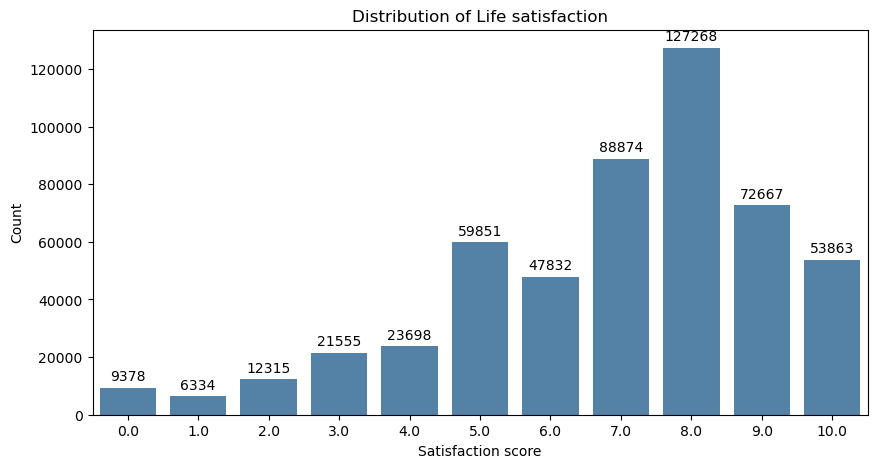

In [275]:
value_count = ess["stflife"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=value_count.index,
    y=value_count.values,
    color="steelblue"
)

plt.title("Distribution of Life satisfaction")
plt.xlabel("Satisfaction score")
plt.ylabel("Count")

# adding counts on top of bars
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.show()

Now, I am grouping categories to create 3 categories:

1. Low: 0–4 (dissatisfied)

2. Medium: 5–6 (neutral / moderately satisfied)

3. High: 7–10 (satisfied / very satisfied)

I am aware that this will make the data imbalanced, however, we still choose it since this approach keeps the data most realistic.

In [276]:
def categorize_life_satisfaction(x):
    if x <= 4:
        return 1 #low satisfaction
    elif x <= 6:
        return 2 # medium satisfaction
    else:
        return 3 #high satisfaction

ess["stflife"] = ess["stflife"].apply(categorize_life_satisfaction)

print(ess["stflife"].value_counts().sort_index())


stflife
1     73280
2    107683
3    342672
Name: count, dtype: int64


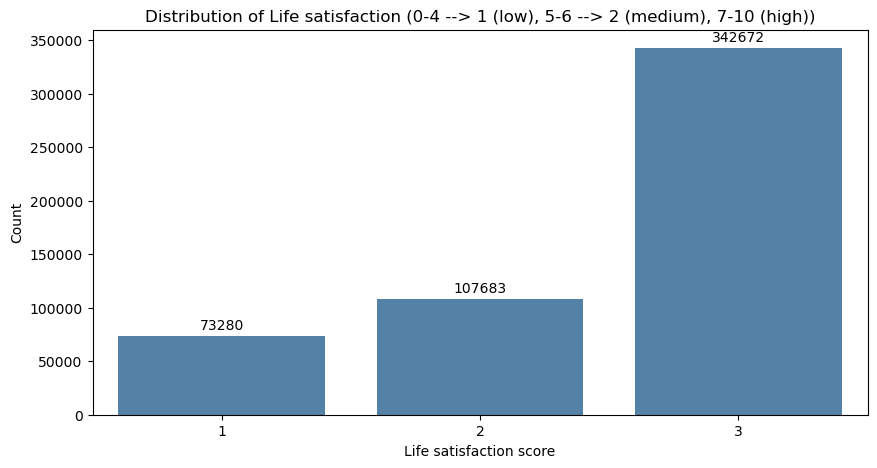

In [277]:
value_count = ess["stflife"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=value_count.index,
    y=value_count.values,
    color="steelblue"
)

plt.title("Distribution of Life satisfaction (0-4 --> 1 (low), 5-6 --> 2 (medium), 7-10 (high))")
plt.xlabel("Life satisfaction score")
plt.ylabel("Count")

# adding counts on top of bars
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.show()




### Save the full dataset to csv

In [280]:
ess.to_csv("ess_final_stflife.csv", index=False)

# 5. Train and test split

Spliiting the data into train and test four times, for each target variable.

Stratification was used in the train-tests split to preserve the distribution of the target variable. 

In [278]:
from sklearn.model_selection import train_test_split

target_variable = "stflife"

X = ess[feature_list]
y = ess[target_variable]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts().sort_index())


(418908, 32) (104727, 32)
stflife
1     58624
2     86146
3    274138
Name: count, dtype: int64


In [279]:
# save features
X_train.to_csv("X_train_stflife.csv", index=False)
X_test.to_csv("X_test_stflife.csv", index=False)

# save target
y_train.to_csv("y_train_stflife.csv", index=False)
y_test.to_csv("y_test_stflife.csv", index=False)

### Notes:

1. ML model - ordered logistic regression (with target variable stflife having 3 levels)


### **2. What preprocessing needs to be done in GOLD?**

In silver we do most of the preprocessing, so that the dataset is ready for modelling in Gold, however, some transformations need to be done in Gold as it is done as a part of ML modelling (I was not sure at the beginning but after confriming with ChatGPT and Gemini, I am convinced that it is a step of ML and should be done in Gold.

The preprocessing needed in gold:

#### **1. Impute missing values (based on train to avoid data leakage):**
- for numeric variables - impute missing values with median
- for ordinal variables - since they are ordered - either impute with mode or median
- for nominal variables - impute with with "-1" (so that is stays as missing because filling in with mode is too risky)

#### **2. Encode predictors:**

- nominal variables - One hot encode
- Ordinal and numeric - keep as they are - do not encode (ordinal can be treated as numeric since they are ordered and their range is {0,1,2,3,...} or {1,2,3..} so the values have a correct distance from one another - no actions needed.)

#### **3. Vector assembly**

ChatGPT: "Spark ML requires all features to be combined into a single column of type Vector.
In Pandas, you just give the model a DataFrame. In Spark (Big Data), the model expects a very specific schema: one column for the Label and one single column called Features that contains a dense or sparse vector of all your data."

#### **4. Scaling of numeric variables**
Scale numeric features (I think with Z-score)
